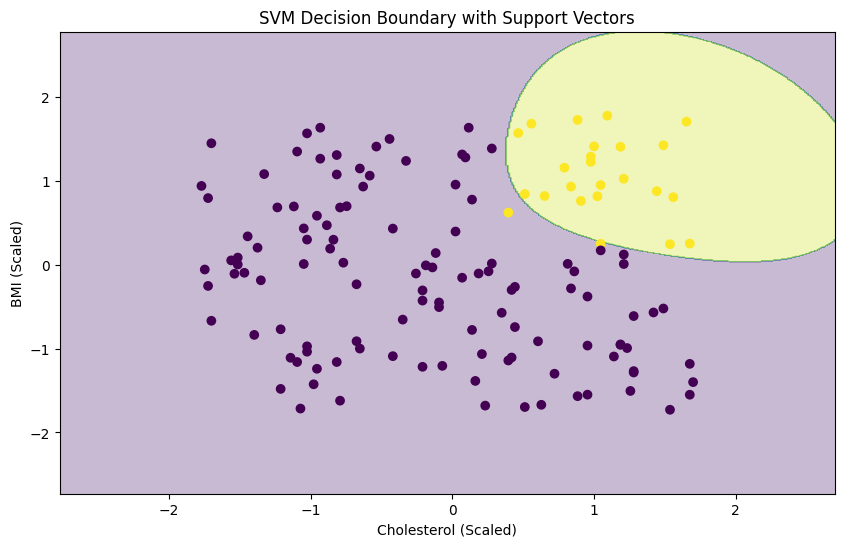

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Generate synthetic data (200 records)
np.random.seed(0)
n = 200

cholesterol = np.random.randint(150, 300, n)
bmi = np.random.uniform(18, 40, n)

# Logical rule
heart_disease = []
for i in range(n):
    if cholesterol[i] > 240 and bmi[i] > 30:
        heart_disease.append(1)
    else:
        heart_disease.append(0)

X = np.column_stack((cholesterol, bmi))
y = np.array(heart_disease)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

# Create mesh grid for plotting decision boundary
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)

# Highlight support vectors
plt.scatter(svm.support_vectors_[:, 0],
            svm.support_vectors_[:, 1],
            s=100, facecolors='none')

plt.xlabel("Cholesterol (Scaled)")
plt.ylabel("BMI (Scaled)")
plt.title("SVM Decision Boundary with Support Vectors")
plt.show()